# NutriVision Food-101 — Inference Model dari ZIP + Rekomendasi Gemini

Notebook ini sudah disesuaikan dengan ZIP model yang berisi:

- `best_nutrivision_cnn_food101_akg.keras`
- `class_names.json`
- `nutrition_table_cleaned.csv`
- `akg_normal.csv`
- `akg_pregnant.csv`
- `akg_breastfeeding.csv`
- `training_log.csv`

Alur notebook:

1. Upload ZIP model.
2. Extract ZIP.
3. Deteksi otomatis file model, label, tabel nutrisi, dan AKG.
4. Load model dengan custom layer `NutritionFromClassProbability`.
5. Upload gambar makanan.
6. Prediksi kelas makanan dan estimasi nutrisi.
7. Bandingkan nutrisi dengan AKG harian.
8. Buat rekomendasi makanan dengan Gemini API.

> Catatan: hasil nutrisi adalah estimasi dari model/tabel referensi, bukan pengganti saran dokter atau ahli gizi.

## 1. Install dan import library

In [ ]:
!pip install -q -U google-genai

import os
import glob
import json
import zipfile
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


## 2. Upload ZIP model

Upload file ZIP model kamu, misalnya `6401 00077.zip`.

In [ ]:
from google.colab import files

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("Belum ada file ZIP yang diupload.")

ZIP_PATH = list(uploaded.keys())[0]
print("ZIP yang dipakai:", ZIP_PATH)

Saving 6401 00077.zip to 6401 00077 (1).zip
ZIP yang dipakai: 6401 00077 (1).zip


## 3. Extract ZIP dan deteksi file penting

In [ ]:
EXTRACT_DIR = "/content/nutrivision_model"
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Isi folder hasil extract:")
for root, dirs, files_ in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files_:
        print(f"{indent}  {f}")

Isi folder hasil extract:
nutrivision_model/
  6401 00077/
    nutrition_table_cleaned.csv
    class_names.json
    akg_breastfeeding (1).csv
    training_log.csv
    akg_pregnant (1).csv
    best_nutrivision_cnn_food101_akg.keras
    akg_normal (2).csv


In [ ]:
def find_files(pattern):
    return glob.glob(os.path.join(EXTRACT_DIR, "**", pattern), recursive=True)

keras_files = find_files("*.keras")
class_files = find_files("class_names.json")
nutrition_files = find_files("nutrition_table*.csv")
akg_normal_files = [p for p in find_files("*.csv") if "akg_normal" in os.path.basename(p).lower()]
akg_pregnant_files = [p for p in find_files("*.csv") if "akg_pregnant" in os.path.basename(p).lower()]
akg_breastfeeding_files = [p for p in find_files("*.csv") if "akg_breastfeeding" in os.path.basename(p).lower()]
log_files = [p for p in find_files("*.csv") if "training_log" in os.path.basename(p).lower()]

print("Model ditemukan:", keras_files)
print("Class names ditemukan:", class_files)
print("Nutrition table ditemukan:", nutrition_files)
print("AKG normal ditemukan:", akg_normal_files)
print("AKG pregnant ditemukan:", akg_pregnant_files)
print("AKG breastfeeding ditemukan:", akg_breastfeeding_files)
print("Training log ditemukan:", log_files)

if not keras_files:
    raise FileNotFoundError("File .keras tidak ditemukan di dalam ZIP.")
if not class_files:
    raise FileNotFoundError("class_names.json tidak ditemukan di dalam ZIP.")
if not nutrition_files:
    raise FileNotFoundError("nutrition_table*.csv tidak ditemukan di dalam ZIP.")

best_candidates = [p for p in keras_files if "best" in os.path.basename(p).lower()]
MODEL_PATH = best_candidates[0] if best_candidates else keras_files[0]
CLASS_PATH = class_files[0]
NUTRITION_PATH = nutrition_files[0]
AKG_NORMAL_PATH = akg_normal_files[0] if akg_normal_files else None
AKG_PREGNANT_PATH = akg_pregnant_files[0] if akg_pregnant_files else None
AKG_BREASTFEEDING_PATH = akg_breastfeeding_files[0] if akg_breastfeeding_files else None
LOG_PATH = log_files[0] if log_files else None

print("PATH YANG DIPAKAI:")
print("MODEL_PATH:", MODEL_PATH)
print("CLASS_PATH:", CLASS_PATH)
print("NUTRITION_PATH:", NUTRITION_PATH)
print("AKG_NORMAL_PATH:", AKG_NORMAL_PATH)
print("AKG_PREGNANT_PATH:", AKG_PREGNANT_PATH)
print("AKG_BREASTFEEDING_PATH:", AKG_BREASTFEEDING_PATH)
print("LOG_PATH:", LOG_PATH)

Model ditemukan: ['/content/nutrivision_model/6401 00077/best_nutrivision_cnn_food101_akg.keras']
Class names ditemukan: ['/content/nutrivision_model/6401 00077/class_names.json']
Nutrition table ditemukan: ['/content/nutrivision_model/6401 00077/nutrition_table_cleaned.csv']
AKG normal ditemukan: ['/content/nutrivision_model/6401 00077/akg_normal (2).csv']
AKG pregnant ditemukan: ['/content/nutrivision_model/6401 00077/akg_pregnant (1).csv']
AKG breastfeeding ditemukan: ['/content/nutrivision_model/6401 00077/akg_breastfeeding (1).csv']
Training log ditemukan: ['/content/nutrivision_model/6401 00077/training_log.csv']
PATH YANG DIPAKAI:
MODEL_PATH: /content/nutrivision_model/6401 00077/best_nutrivision_cnn_food101_akg.keras
CLASS_PATH: /content/nutrivision_model/6401 00077/class_names.json
NUTRITION_PATH: /content/nutrivision_model/6401 00077/nutrition_table_cleaned.csv
AKG_NORMAL_PATH: /content/nutrivision_model/6401 00077/akg_normal (2).csv
AKG_PREGNANT_PATH: /content/nutrivision_mo

## 4. Load model dengan custom layer

Model kamu memakai custom layer `NutritionFromClassProbability`. Jadi custom layer ini wajib didefinisikan dan didaftarkan sebelum `keras.models.load_model()` dijalankan.

In [ ]:
@keras.saving.register_keras_serializable(package="NutriVision", name="NutritionFromClassProbability")
class NutritionFromClassProbability(keras.layers.Layer):
    def __init__(self, nutrition_table_norm, **kwargs):
        super().__init__(**kwargs)
        self.nutrition_table_norm = np.array(nutrition_table_norm, dtype="float32")

    def build(self, input_shape):
        self.nutrition_table = self.add_weight(
            name="nutrition_table",
            shape=self.nutrition_table_norm.shape,
            initializer=keras.initializers.Constant(self.nutrition_table_norm),
            trainable=False,
        )
        super().build(input_shape)

    def call(self, class_probs):
        return keras.ops.matmul(class_probs, self.nutrition_table)

    def get_config(self):
        config = super().get_config()
        config.update({
            "nutrition_table_norm": self.nutrition_table_norm.tolist()
        })
        return config

    @classmethod
    def from_config(cls, config):
        nutrition_table_norm = config.pop("nutrition_table_norm")
        return cls(nutrition_table_norm=nutrition_table_norm, **config)


# Tambahan manual agar aman untuk model yang tersimpan sebagai NutriVision>NutritionFromClassProbability
keras.saving.get_custom_objects()["NutritionFromClassProbability"] = NutritionFromClassProbability
keras.saving.get_custom_objects()["NutriVision>NutritionFromClassProbability"] = NutritionFromClassProbability

custom_objects = {
    "NutritionFromClassProbability": NutritionFromClassProbability,
    "NutriVision>NutritionFromClassProbability": NutritionFromClassProbability,
}

with keras.saving.custom_object_scope(custom_objects):
    model = keras.models.load_model(
        MODEL_PATH,
        custom_objects=custom_objects,
        compile=False,
        safe_mode=False,
    )

with open(CLASS_PATH, "r") as f:
    CLASS_NAMES = json.load(f)

nutrition_df = pd.read_csv(NUTRITION_PATH)

if "class_name" not in nutrition_df.columns:
    raise ValueError("Kolom class_name tidak ditemukan pada nutrition table.")

NUTRIENT_COLS = [c for c in nutrition_df.columns if c != "class_name"]

print("Model berhasil diload.")
print("Jumlah kelas:", len(CLASS_NAMES))
print("Input shape model:", model.input_shape)
print("Output names:", getattr(model, "output_names", None))
print("Output shape:", model.output_shape)
print("Kolom nutrisi:", NUTRIENT_COLS)

display(nutrition_df.head())

Model berhasil diload.
Jumlah kelas: 101
Input shape model: (None, 224, 224, 3)
Output names: ListWrapper(['class_output', 'nutrition_output'])
Output shape: [(None, 101), (None, 8)]
Kolom nutrisi: ['calories_kcal', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'calcium_mg', 'iron_mg', 'vitamin_c_mg']


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,360.531380,8.448368,51.013617,16.042086,1.856476,80.564335,1.737752,3.485936
1,baby_back_ribs,300.050396,11.653377,28.921127,18.032969,1.981891,79.009366,1.858384,4.800256
2,baklava,359.228632,8.448368,28.921127,15.922833,1.856476,89.826141,1.799675,3.485936
3,beef_carpaccio,301.734171,11.653377,27.987210,17.759368,1.982885,78.561907,1.858384,4.939265
4,beef_tartare,304.032317,11.653377,28.921127,18.151466,1.994065,80.685123,1.858384,5.284609


## 5. Cek log training, opsional

In [ ]:
if LOG_PATH is not None:
    log_df = pd.read_csv(LOG_PATH)
    display(log_df.tail())

    if "val_class_output_accuracy" in log_df.columns:
        best_row = log_df.loc[log_df["val_class_output_accuracy"].idxmax()]
        print("Epoch terbaik berdasarkan val_class_output_accuracy:", int(best_row["epoch"]))
        print("Validation accuracy terbaik:", float(best_row["val_class_output_accuracy"]))
        print("Validation nutrition MAE:", float(best_row.get("val_nutrition_output_mae", np.nan)))
else:
    print("training_log.csv tidak ditemukan, bagian ini dilewati.")

,epoch,class_output_accuracy,class_output_loss,loss,nutrition_output_loss,nutrition_output_mae,val_class_output_accuracy,val_class_output_loss,val_loss,val_nutrition_output_loss,val_nutrition_output_mae
95,95,0.722363,1.402707,1.403167,0.007004,0.007002,0.635881,1.776759,1.775662,0.007796,0.007794
96,96,0.724607,1.398768,1.399421,0.007030,0.007029,0.639010,1.761626,1.763804,0.007720,0.007724
97,97,0.724224,1.401499,1.402156,0.007009,0.007008,0.637782,1.772805,1.775015,0.007760,0.007766
98,98,0.723987,1.398378,1.399005,0.007007,0.007007,0.636673,1.771969,1.773895,0.007755,0.007758
99,99,0.724079,1.400704,1.401164,0.006988,0.006986,0.637941,1.771524,1.770819,0.007747,0.007740


Epoch terbaik berdasarkan val_class_output_accuracy: 87
Validation accuracy terbaik: 0.6400792002677917
Validation nutrition MAE: 0.0076951505616307


## 6. Fungsi inference gambar

Model kamu memiliki dua output:

- `class_output`: probabilitas kelas makanan.
- `nutrition_output`: estimasi nutrisi yang masih dalam bentuk normalisasi.

Pada ZIP kamu, normalisasi nutrisi mengikuti skala:

- kalori `/1000`
- protein `/100`
- karbohidrat `/160`
- lemak `/100`
- serat `/50`
- kalsium `/1600`
- zat besi `/30`
- vitamin C `/200`

In [ ]:
IMG_SIZE = 224

DEFAULT_DENORM_SCALE = {
    "calories_kcal": 1000.0,
    "protein_g": 100.0,
    "carbs_g": 160.0,
    "fat_g": 100.0,
    "fiber_g": 50.0,
    "calcium_mg": 1600.0,
    "iron_mg": 30.0,
    "vitamin_c_mg": 200.0,
}

nutrition_lookup = nutrition_df.set_index("class_name")[NUTRIENT_COLS]


def load_image_for_model(img_path, img_size=IMG_SIZE):
    """Load gambar menjadi batch tensor shape (1, 224, 224, 3)."""
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize((img_size, img_size))
    arr = np.array(img_resized).astype("float32")
    batch = np.expand_dims(arr, axis=0)
    return img, batch


def split_model_outputs(outputs):
    """Ambil output class dan nutrisi dari output model, baik dict/list/tuple."""
    if isinstance(outputs, dict):
        class_probs = outputs.get("class_output")
        nutrition_norm = outputs.get("nutrition_output")
    elif isinstance(outputs, (list, tuple)):
        output_names = getattr(model, "output_names", [])
        output_map = dict(zip(output_names, outputs))
        class_probs = output_map.get("class_output", outputs[0])
        nutrition_norm = output_map.get("nutrition_output", outputs[1] if len(outputs) > 1 else None)
    else:
        raise ValueError("Format output model tidak dikenali.")

    if class_probs is None:
        raise ValueError("class_output tidak ditemukan pada output model.")

    return np.asarray(class_probs), None if nutrition_norm is None else np.asarray(nutrition_norm)


def denormalize_nutrition(norm_values):
    """Ubah nutrition_output model dari skala normalisasi ke satuan nutrisi asli."""
    values = {}
    for i, col in enumerate(NUTRIENT_COLS):
        scale = DEFAULT_DENORM_SCALE.get(col, 1.0)
        values[col] = float(norm_values[i]) * scale
    return pd.Series(values)


def format_food_name(class_name):
    return class_name.replace("_", " ").title()


def predict_food_image(img_path, portion_gram=100, top_k=5, show_model_nutrition=True):
    img, batch = load_image_for_model(img_path)

    outputs = model.predict(batch, verbose=0)
    class_probs, nutrition_norm = split_model_outputs(outputs)

    probs = class_probs[0]
    top_indices = np.argsort(probs)[::-1][:top_k]
    pred_index = int(top_indices[0])
    pred_class = CLASS_NAMES[pred_index]
    confidence = float(probs[pred_index])

    # Estimasi gizi dari tabel referensi berdasarkan kelas prediksi
    table_nutrition_100g = nutrition_lookup.loc[pred_class].astype(float)
    table_nutrition_portion = table_nutrition_100g * (portion_gram / 100.0)

    # Estimasi gizi dari output model
    model_nutrition_portion = None
    if nutrition_norm is not None:
        model_nutrition_100g = denormalize_nutrition(nutrition_norm[0])
        model_nutrition_portion = model_nutrition_100g * (portion_gram / 100.0)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {format_food_name(pred_class)} ({confidence*100:.2f}%)")
    plt.show()

    top_df = pd.DataFrame({
        "rank": list(range(1, len(top_indices) + 1)),
        "class_name": [CLASS_NAMES[int(i)] for i in top_indices],
        "food_name": [format_food_name(CLASS_NAMES[int(i)]) for i in top_indices],
        "confidence_percent": [float(probs[int(i)]) * 100 for i in top_indices],
    })

    table_result_df = table_nutrition_portion.reset_index()
    table_result_df.columns = ["nutrient", "estimated_value"]

    print("=== TOP PREDIKSI MAKANAN ===")
    display(top_df)

    print(f"=== ESTIMASI GIZI DARI TABEL REFERENSI ({portion_gram} gram) ===")
    display(table_result_df)

    model_result_df = None
    if show_model_nutrition and model_nutrition_portion is not None:
        model_result_df = model_nutrition_portion.reset_index()
        model_result_df.columns = ["nutrient", "estimated_value"]
        print(f"=== ESTIMASI GIZI DARI OUTPUT MODEL ({portion_gram} gram) ===")
        display(model_result_df)

    return {
        "image_path": img_path,
        "portion_gram": portion_gram,
        "predicted_class": pred_class,
        "predicted_food_name": format_food_name(pred_class),
        "confidence": confidence,
        "confidence_percent": confidence * 100,
        "top_predictions": top_df,
        "nutrition_from_table": table_nutrition_portion,
        "nutrition_from_model": model_nutrition_portion,
        "nutrition_table_df": table_result_df,
        "nutrition_model_df": model_result_df,
    }

## 7. Upload gambar makanan dan jalankan prediksi

Saving icecream.jpeg to icecream.jpeg
Masukkan estimasi berat/porsi makanan dalam gram. Tekan Enter untuk default 100 gram: 100
Memproses: icecream.jpeg


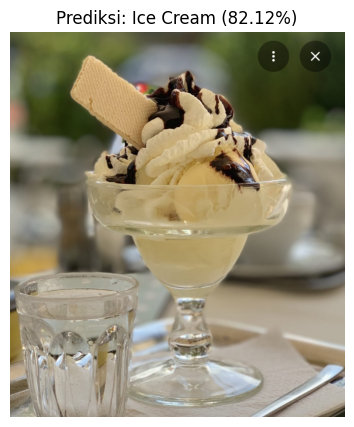

=== TOP PREDIKSI MAKANAN ===


,rank,class_name,food_name,confidence_percent
0,1,ice_cream,Ice Cream,82.117707
1,2,frozen_yogurt,Frozen Yogurt,13.087659
2,3,tiramisu,Tiramisu,1.124828
3,4,panna_cotta,Panna Cotta,0.815788
4,5,chocolate_mousse,Chocolate Mousse,0.628412


=== ESTIMASI GIZI DARI TABEL REFERENSI (100.0 gram) ===


,nutrient,estimated_value
0,calories_kcal,357.217333
1,protein_g,9.411889
2,carbs_g,52.006647
3,fat_g,15.632926
4,fiber_g,1.856476
5,calcium_mg,102.115426
6,iron_mg,1.799675
7,vitamin_c_mg,3.485936


=== ESTIMASI GIZI DARI OUTPUT MODEL (100.0 gram) ===


,nutrient,estimated_value
0,calories_kcal,341.330588
1,protein_g,9.399989
2,carbs_g,48.663349
3,fat_g,16.856503
4,fiber_g,1.876228
5,calcium_mg,98.670274
6,iron_mg,1.797568
7,vitamin_c_mg,3.658538


Hasil utama tersimpan di variabel: result


In [ ]:
from google.colab import files

uploaded_images = files.upload()

if len(uploaded_images) == 0:
    raise ValueError("Belum ada gambar makanan yang diupload.")

portion_input = input("Masukkan estimasi berat/porsi makanan dalam gram. Tekan Enter untuk default 100 gram: ").strip()
portion_gram = float(portion_input) if portion_input else 100.0

results = []
for img_path in uploaded_images.keys():
    print("Memproses:", img_path)
    result = predict_food_image(img_path, portion_gram=portion_gram, top_k=5)
    results.append(result)

result = results[0]
print("Hasil utama tersimpan di variabel: result")

Saving icecre4am1.jpeg to icecre4am1.jpeg
Masukkan estimasi berat/porsi makanan dalam gram. Tekan Enter untuk default 100 gram: 100
Memproses: icecre4am1.jpeg


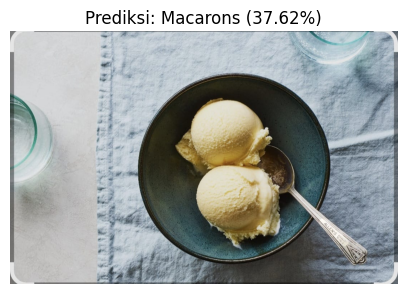

=== TOP PREDIKSI MAKANAN ===


,rank,class_name,food_name,confidence_percent
0,1,macarons,Macarons,37.619933
1,2,ice_cream,Ice Cream,13.524641
2,3,cheesecake,Cheesecake,11.189607
3,4,foie_gras,Foie Gras,4.631814
4,5,tiramisu,Tiramisu,4.486871


=== ESTIMASI GIZI DARI TABEL REFERENSI (100.0 gram) ===


,nutrient,estimated_value
0,calories_kcal,360.556982
1,protein_g,9.989118
2,carbs_g,51.813578
3,fat_g,15.901340
4,fiber_g,1.856476
5,calcium_mg,92.138246
6,iron_mg,1.737752
7,vitamin_c_mg,3.485936


=== ESTIMASI GIZI DARI OUTPUT MODEL (100.0 gram) ===


,nutrient,estimated_value
0,calories_kcal,333.912611
1,protein_g,9.655374
2,carbs_g,46.070075
3,fat_g,15.153027
4,fiber_g,1.896218
5,calcium_mg,92.288107
6,iron_mg,1.779179
7,vitamin_c_mg,3.892141


Hasil utama tersimpan di variabel: result


In [ ]:
from google.colab import files

uploaded_images = files.upload()

if len(uploaded_images) == 0:
    raise ValueError("Belum ada gambar makanan yang diupload.")

portion_input = input("Masukkan estimasi berat/porsi makanan dalam gram. Tekan Enter untuk default 100 gram: ").strip()
portion_gram = float(portion_input) if portion_input else 100.0

results = []
for img_path in uploaded_images.keys():
    print("Memproses:", img_path)
    result = predict_food_image(img_path, portion_gram=portion_gram, top_k=5)
    results.append(result)

result = results[0]
print("Hasil utama tersimpan di variabel: result")

Saving nasgor1.jpeg to nasgor1.jpeg
Masukkan estimasi berat/porsi makanan dalam gram. Tekan Enter untuk default 100 gram: 250
Memproses: nasgor1.jpeg


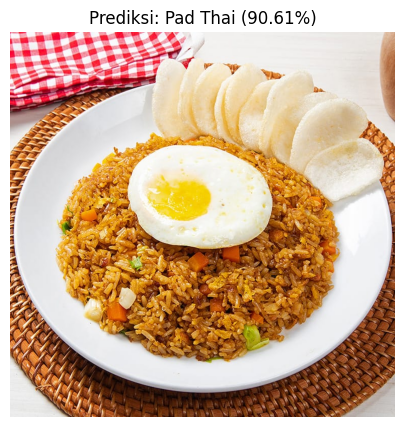

=== TOP PREDIKSI MAKANAN ===


,rank,class_name,food_name,confidence_percent
0,1,pad_thai,Pad Thai,90.610474
1,2,fried_rice,Fried Rice,3.451076
2,3,paella,Paella,2.022787
3,4,ramen,Ramen,0.761440
4,5,fried_calamari,Fried Calamari,0.622282


=== ESTIMASI GIZI DARI TABEL REFERENSI (250.0 gram) ===


,nutrient,estimated_value
0,calories_kcal,586.784110
1,protein_g,25.068844
2,carbs_g,68.612873
3,fat_g,25.223142
4,fiber_g,4.985383
5,calcium_mg,201.410838
6,iron_mg,4.499187
7,vitamin_c_mg,11.410084


=== ESTIMASI GIZI DARI OUTPUT MODEL (250.0 gram) ===


,nutrient,estimated_value
0,calories_kcal,601.967536
1,protein_g,25.049884
2,carbs_g,70.843267
3,fat_g,26.329981
4,fiber_g,4.988154
5,calcium_mg,201.495200
6,iron_mg,4.502259
7,vitamin_c_mg,11.504529


Hasil utama tersimpan di variabel: result


In [ ]:
from google.colab import files

uploaded_images = files.upload()

if len(uploaded_images) == 0:
    raise ValueError("Belum ada gambar makanan yang diupload.")

portion_input = input("Masukkan estimasi berat/porsi makanan dalam gram. Tekan Enter untuk default 100 gram: ").strip()
portion_gram = float(portion_input) if portion_input else 100.0

results = []
for img_path in uploaded_images.keys():
    print("Memproses:", img_path)
    result = predict_food_image(img_path, portion_gram=portion_gram, top_k=5)
    results.append(result)

result = results[0]
print("Hasil utama tersimpan di variabel: result")

Saving burger.webp to burger.webp
Masukkan estimasi berat/porsi makanan dalam gram. Tekan Enter untuk default 100 gram: 200
Memproses: burger.webp


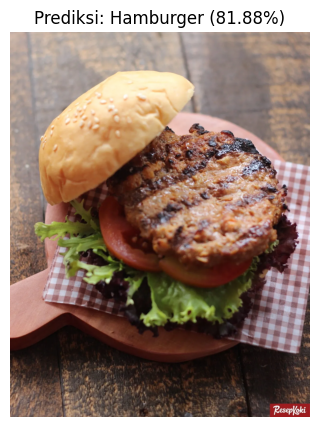

=== TOP PREDIKSI MAKANAN ===


,rank,class_name,food_name,confidence_percent
0,1,hamburger,Hamburger,81.879997
1,2,pulled_pork_sandwich,Pulled Pork Sandwich,14.675361
2,3,club_sandwich,Club Sandwich,0.888552
3,4,lobster_roll_sandwich,Lobster Roll Sandwich,0.321657
4,5,steak,Steak,0.216255


=== ESTIMASI GIZI DARI TABEL REFERENSI (200.0 gram) ===


,nutrient,estimated_value
0,calories_kcal,606.556190
1,protein_g,23.306755
2,carbs_g,55.270481
3,fat_g,36.212837
4,fiber_g,3.987611
5,calcium_mg,160.490824
6,iron_mg,3.716769
7,vitamin_c_mg,9.861318


=== ESTIMASI GIZI DARI OUTPUT MODEL (200.0 gram) ===


,nutrient,estimated_value
0,calories_kcal,603.637040
1,protein_g,23.237561
2,carbs_g,58.917036
3,fat_g,35.724592
4,fiber_g,3.988295
5,calcium_mg,160.258222
6,iron_mg,3.696873
7,vitamin_c_mg,9.850010


Hasil utama tersimpan di variabel: result


In [ ]:
from google.colab import files

uploaded_images = files.upload()

if len(uploaded_images) == 0:
    raise ValueError("Belum ada gambar makanan yang diupload.")

portion_input = input("Masukkan estimasi berat/porsi makanan dalam gram. Tekan Enter untuk default 100 gram: ").strip()
portion_gram = float(portion_input) if portion_input else 100.0

results = []
for img_path in uploaded_images.keys():
    print("Memproses:", img_path)
    result = predict_food_image(img_path, portion_gram=portion_gram, top_k=5)
    results.append(result)

result = results[0]
print("Hasil utama tersimpan di variabel: result")

## 8. Fungsi AKG / kebutuhan gizi harian

Bagian ini memakai tabel AKG yang ada di ZIP untuk membandingkan estimasi nutrisi makanan dengan kebutuhan harian pengguna.

In [ ]:
AKG_MAP = {
    "calories_kcal": "calories",
    "protein_g": "protein",
    "carbs_g": "carbohydrates",
    "fat_g": "total_fat",
    "fiber_g": "dietary_fiber",
    "calcium_mg": "calcium",
    "iron_mg": "iron",
    "vitamin_c_mg": "vitamin_c",
}


def _load_akg_df(path):
    if path is None:
        return None
    return pd.read_csv(path)


def get_akg_target(age, sex="male", condition="normal", pregnancy_month=None, breastfeeding_month=None):
    """
    age: usia dalam tahun
    sex: "male" atau "female"
    condition: "normal", "pregnant", atau "breastfeeding"
    """
    if AKG_NORMAL_PATH is None:
        raise FileNotFoundError("File AKG normal tidak ditemukan di ZIP.")

    normal_df = pd.read_csv(AKG_NORMAL_PATH)
    sex = sex.lower().strip()
    condition = condition.lower().strip()

    if age < 10:
        base = normal_df[
            (normal_df["age_category"] == "infants_children") &
            (normal_df["min_age"] <= age) &
            (normal_df["max_age"] >= age)
        ]
    else:
        base = normal_df[
            (normal_df["age_category"] == sex) &
            (normal_df["min_age"] <= age) &
            (normal_df["max_age"] >= age)
        ]

    if base.empty:
        raise ValueError("AKG tidak ditemukan untuk profil tersebut. Cek age dan sex.")

    target = base.iloc[0].copy()

    if condition == "pregnant":
        if AKG_PREGNANT_PATH is None:
            raise FileNotFoundError("File AKG pregnant tidak ditemukan di ZIP.")
        if pregnancy_month is None:
            raise ValueError("Isi pregnancy_month untuk kondisi pregnant.")

        preg_df = pd.read_csv(AKG_PREGNANT_PATH)
        inc = preg_df[
            (preg_df["age_category"] == "pregnant") &
            (preg_df["preg_month_min"] <= pregnancy_month) &
            (preg_df["preg_month_max"] >= pregnancy_month)
        ]

        if not inc.empty:
            for akg_col in AKG_MAP.values():
                target[akg_col] = float(target[akg_col]) + float(inc.iloc[0][akg_col])

    elif condition == "breastfeeding":
        if AKG_BREASTFEEDING_PATH is None:
            raise FileNotFoundError("File AKG breastfeeding tidak ditemukan di ZIP.")
        if breastfeeding_month is None:
            raise ValueError("Isi breastfeeding_month untuk kondisi breastfeeding.")

        bf_df = pd.read_csv(AKG_BREASTFEEDING_PATH)
        inc = bf_df[
            (bf_df["age_category"] == "breastfeeding") &
            (bf_df["bf_month_min"] <= breastfeeding_month) &
            (bf_df["bf_month_max"] >= breastfeeding_month)
        ]

        if not inc.empty:
            for akg_col in AKG_MAP.values():
                target[akg_col] = float(target[akg_col]) + float(inc.iloc[0][akg_col])

    selected_target = {}
    for pred_col, akg_col in AKG_MAP.items():
        if pred_col in NUTRIENT_COLS and akg_col in target.index:
            selected_target[pred_col] = float(target[akg_col])

    return selected_target


def compare_nutrition_with_akg(nutrition_series, akg_target):
    rows = []
    for nutrient, predicted_amount in nutrition_series.items():
        target = float(akg_target.get(nutrient, np.nan))
        predicted_amount = float(predicted_amount)
        percent = (predicted_amount / target * 100.0) if target and not np.isnan(target) else np.nan
        rows.append({
            "nutrient": nutrient,
            "predicted_amount": predicted_amount,
            "daily_target_akg": target,
            "percent_of_daily_need": percent,
        })
    return pd.DataFrame(rows)

## 9. Isi profil user dan bandingkan dengan AKG

Ubah data berikut sesuai pengguna aplikasi.

In [ ]:
USER_PROFILE = {
    "age": 21,
    "sex": "male",              # "male" atau "female"
    "condition": "normal",      # "normal", "pregnant", atau "breastfeeding"
    "pregnancy_month": None,
    "breastfeeding_month": None,
}

akg_target = get_akg_target(
    age=USER_PROFILE["age"],
    sex=USER_PROFILE["sex"],
    condition=USER_PROFILE["condition"],
    pregnancy_month=USER_PROFILE["pregnancy_month"],
    breastfeeding_month=USER_PROFILE["breastfeeding_month"],
)

# Untuk rekomendasi, pakai nutrition_from_table karena biasanya lebih stabil untuk demo.
# Jika ingin memakai output model, ganti ke result["nutrition_from_model"]
nutrition_for_recommendation = result["nutrition_from_table"]

comparison_df = compare_nutrition_with_akg(nutrition_for_recommendation, akg_target)

print("Target AKG:")
print(json.dumps(akg_target, indent=2))

print("Perbandingan nutrisi makanan dengan AKG:")
display(comparison_df)

Target AKG:
{
  "calories_kcal": 2650.0,
  "protein_g": 65.0,
  "carbs_g": 430.0,
  "fat_g": 75.0,
  "fiber_g": 37.0,
  "calcium_mg": 1000.0,
  "iron_mg": 9.0,
  "vitamin_c_mg": 90.0
}
Perbandingan nutrisi makanan dengan AKG:


,nutrient,predicted_amount,daily_target_akg,percent_of_daily_need
0,calories_kcal,357.217333,2650.0,13.479899
1,protein_g,9.411889,65.0,14.479829
2,carbs_g,52.006647,430.0,12.094569
3,fat_g,15.632926,75.0,20.843901
4,fiber_g,1.856476,37.0,5.017502
5,calcium_mg,102.115426,1000.0,10.211543
6,iron_mg,1.799675,9.0,19.996387
7,vitamin_c_mg,3.485936,90.0,3.873262


## 10. Rekomendasi nutrisi dengan Gemini API

Cara pakai:

1. Buka menu **Secrets** di Colab.
2. Tambahkan secret dengan nama `GEMINI_API_KEY`.
3. Isi dengan API key dari Google AI Studio.
4. Aktifkan akses notebook ke secret tersebut.

Kalau tidak mau pakai Secrets, cell di bawah juga bisa meminta API key lewat input.

In [ ]:
from google import genai
from google.colab import userdata
import getpass

try:
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = None

if not GEMINI_API_KEY:
    GEMINI_API_KEY = getpass.getpass("Masukkan GEMINI_API_KEY: ")

client = genai.Client(api_key=GEMINI_API_KEY)
print("Gemini client siap.")

Masukkan GEMINI_API_KEY: ··········
Gemini client siap.


In [ ]:
def series_to_plain_dict(series):
    if series is None:
        return None
    return {str(k): float(v) for k, v in series.items()}


def generate_nutrition_recommendation(
    prediction_result,
    user_profile,
    akg_target,
    comparison_df,
    use_model_nutrition=False,
    gemini_model="gemini-2.5-flash",
):
    nutrition_source = "nutrition_from_model" if use_model_nutrition else "nutrition_from_table"
    nutrition_data = series_to_plain_dict(prediction_result.get(nutrition_source))

    top_predictions_json = prediction_result["top_predictions"].to_dict(orient="records")
    comparison_json = comparison_df.to_dict(orient="records")

    prompt = f"""
Kamu adalah asisten rekomendasi gizi untuk aplikasi prediksi nutrisi berbasis gambar makanan.

Gunakan bahasa Indonesia yang mudah dipahami.

Batasan penting:
- Data makanan berasal dari model machine learning, jadi hasilnya hanya estimasi.
- Jangan membuat diagnosis medis.
- Jangan menyarankan diet ekstrem.
- Jangan mengklaim hasil ini pasti benar.
- Berikan rekomendasi yang praktis, aman, dan cocok untuk pengguna umum.

Profil pengguna:
{json.dumps(user_profile, indent=2, ensure_ascii=False)}

Hasil prediksi makanan:
- class: {prediction_result["predicted_class"]}
- nama makanan: {prediction_result["predicted_food_name"]}
- confidence: {prediction_result["confidence_percent"]:.2f}%
- porsi: {prediction_result["portion_gram"]} gram

Top prediksi model:
{json.dumps(top_predictions_json, indent=2, ensure_ascii=False)}

Estimasi nutrisi yang digunakan untuk rekomendasi ({nutrition_source}):
{json.dumps(nutrition_data, indent=2, ensure_ascii=False)}

Target AKG harian pengguna:
{json.dumps(akg_target, indent=2, ensure_ascii=False)}

Perbandingan makanan terhadap AKG harian:
{json.dumps(comparison_json, indent=2, ensure_ascii=False)}

Tugas kamu:
1. Jelaskan makanan yang terdeteksi dan tingkat keyakinan model.
2. Ringkas kandungan nutrisi utama dari makanan tersebut.
3. Jelaskan nutrisi mana yang kontribusinya masih rendah terhadap kebutuhan harian.
4. Berikan rekomendasi makanan/minuman berikutnya untuk melengkapi nutrisi harian.
5. Berikan 3 contoh menu sederhana.
6. Akhiri dengan catatan bahwa hasil ini hanya estimasi dan bukan pengganti saran ahli gizi/dokter.
"""

    response = client.models.generate_content(
        model=gemini_model,
        contents=prompt,
    )

    return response.text


recommendation = generate_nutrition_recommendation(
    prediction_result=result,
    user_profile=USER_PROFILE,
    akg_target=akg_target,
    comparison_df=comparison_df,
    use_model_nutrition=False,
)

print(recommendation)

Halo! Selamat datang di aplikasi prediksi nutrisi kami. Mari kita lihat makananmu hari ini!

**1. Makanan yang Terdeteksi**
Berdasarkan gambar yang kamu unggah, sistem kecerdasan buatan kami mendeteksi bahwa kamu mengonsumsi **Ice Cream** seberat sekitar 100.0 gram dengan tingkat keyakinan sebesar **82.12%**.

Sebagai informasi tambahan, ada kemungkinan juga makanan tersebut adalah *Frozen Yogurt* (13.09% keyakinan) atau *Tiramisu* (1.12% keyakinan), karena tampilannya yang mirip. Namun, prediksi utamanya adalah Ice Cream.

**2. Ringkasan Kandungan Nutrisi Ice Cream (Estimasi per 100 gram)**
Dari estimasi yang kami miliki, 100 gram Ice Cream yang kamu konsumsi mengandung:
*   **Kalori:** Sekitar 357 kkal
*   **Protein:** Sekitar 9.4 gram
*   **Karbohidrat:** Sekitar 52.0 gram
*   **Lemak:** Sekitar 15.6 gram
*   **Serat:** Sekitar 1.9 gram
*   **Kalsium:** Sekitar 102 mg
*   **Zat Besi:** Sekitar 1.8 mg
*   **Vitamin C:** Sekitar 3.5 mg

**3. Kontribusi Nutrisi Terhadap Kebutuhan Haria

## 11. Ringkasan variabel penting

Setelah semua cell dijalankan, variabel penting yang bisa kamu pakai untuk integrasi lanjutan:

- `model`: model Keras yang sudah diload.
- `CLASS_NAMES`: daftar kelas Food-101.
- `nutrition_df`: tabel nutrisi referensi.
- `result`: hasil prediksi gambar pertama.
- `comparison_df`: perbandingan nutrisi dengan AKG.
- `recommendation`: teks rekomendasi dari Gemini.

In [ ]:
print("Prediksi makanan:", result["predicted_food_name"])
print("Confidence:", f"{result['confidence_percent']:.2f}%")
print("Porsi:", result["portion_gram"], "gram")
print("Estimasi nutrisi yang dipakai:")
display(result["nutrition_from_table"].reset_index().rename(columns={"index": "nutrient", 0: "estimated_value"}))

Prediksi makanan: Ice Cream
Confidence: 82.12%
Porsi: 100.0 gram
Estimasi nutrisi yang dipakai:


,nutrient,ice_cream
0,calories_kcal,357.217333
1,protein_g,9.411889
2,carbs_g,52.006647
3,fat_g,15.632926
4,fiber_g,1.856476
5,calcium_mg,102.115426
6,iron_mg,1.799675
7,vitamin_c_mg,3.485936
